In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

mono_df = pd.read_csv('/home/jdweiss1/orcd/scratch/15/mono_data.csv', index_col=0)
mono_df['culture_type'] = 'mono'

co_df = pd.read_csv('/home/jdweiss1/orcd/scratch/15/co_data.csv', index_col=0)
co_df['culture_type'] = 'co'

tri_df = pd.read_csv('/home/jdweiss1/orcd/scratch/15/tri_data.csv', index_col=0)
tri_df['culture_type'] = 'tri'

condition_map = {
    2: 'DMSO',
    3: 'IL1B',
    4: 'Bent',
    5: '3013',
    8: 'DMSO',
    9: 'IL1B',
    10: 'Bent',
    11: '3013'
}

channel_map = {
    'DAPI': 1,
    'Phospho-cJun': 2,
    'ki67': 3,
    'Mac cell trace': 4,
    'EpCAM': 5
}

drug_order = ['DMSO', 'IL1B', 'Bent', '3013']
drug_colors = ['#bfbfbf', '#000000', "#7cb0f9", "#ff94f3"]

donors = [284, 287, 304]
cell_types = ['ESC', 'macrophage', 'epithelial']
culture_types = ['mono', 'co', 'tri']

df = pd.concat([mono_df, co_df, tri_df], ignore_index=True)

df['drug_condition'] = df['well_id'].apply(lambda x: condition_map.get(int(x[1:]), 'Unknown'))

df

,nucleus_id,nuclear_volume_voxels,nuclear_volume_um3,cytoplasm_volume_voxels,cytoplasm_volume_um3,channel_1_nuclear_mean,channel_1_nuclear_max,channel_1_nuclear_std,channel_1_nuclear_integrated,channel_1_cytoplasm_mean,...,nn5_mean_dist,num_neighbors_within_50_um,sphericity,well_id,donor_id,aspect_ratio,nn5_mean_epcam,rf_cell_type,culture_type,drug_condition
0,1,192.0,442.990550,330.0,761.390009,250.18750,299.0,17.220272,4.803600e+04,243.081818,...,10.246000,97,0.490531,B08,284,5.533358,727.502362,epithelial,mono,DMSO
1,2,168.0,387.616732,350.0,807.534857,249.82143,293.0,17.184338,4.197000e+04,241.748566,...,11.381760,95,0.532853,B08,284,3.869132,731.104840,epithelial,mono,DMSO
2,3,180.0,415.303641,269.0,620.648219,248.51666,313.0,18.597933,4.473300e+04,242.420074,...,9.693149,93,0.533505,B08,284,3.016692,732.411900,epithelial,mono,DMSO
3,4,3884.0,8961.329676,2022.0,4665.244234,261.84784,353.0,20.722052,1.017017e+06,258.114746,...,9.515501,158,0.429715,B08,284,2.842679,730.269252,epithelial,mono,DMSO
4,5,120.0,276.869094,228.0,526.051279,247.58333,314.0,16.766825,2.971000e+04,243.732452,...,11.977551,92,0.545857,B08,284,NaN,734.998368,epithelial,mono,DMSO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695252,5140,136.0,313.784973,2080.0,4799.064296,1144.41910,1799.0,304.211330,1.556410e+05,365.024994,...,51.164359,2,0.735730,F05,304,NaN,695.745220,ESC,tri,3013
695253,5141,68.0,156.892487,1798.0,4148.421925,1568.85290,1988.0,247.854500,1.066820e+05,605.893188,...,59.378971,0,0.710171,F05,304,NaN,633.024568,ESC,tri,3013
695254,5142,164.0,378.387762,2160.0,4983.643692,1105.78050,1799.0,319.092320,1.813480e+05,291.804169,...,80.724330,0,0.744535,F05,304,NaN,1772.797080,macrophage,tri,3013
695255,5143,124.0,286.098064,2084.0,4808.293266,1011.94354,1519.0,221.170400,1.254810e+05,301.449615,...,72.105416,1,0.684182,F05,304,NaN,1718.059140,macrophage,tri,3013


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm


features = ['nuclear_volume_voxels', 'cytoplasm_volume_voxels', 'channel_1_nuclear_mean', 
            'channel_1_nuclear_max', 'channel_1_nuclear_std', 'channel_1_cytoplasm_mean', 
            'channel_1_cytoplasm_max', 'channel_1_cytoplasm_std', 'channel_1_nc_ratio', 
            'channel_2_nuclear_mean', 'channel_2_nuclear_max', 'channel_2_nuclear_std',
            'channel_2_cytoplasm_mean', 'channel_2_cytoplasm_max', 'channel_2_cytoplasm_std',
            'channel_2_nc_ratio', 'channel_3_nuclear_mean', 'channel_3_nuclear_max',
            'channel_3_nuclear_std', 'channel_3_cytoplasm_mean', 'channel_3_cytoplasm_max',
            'channel_3_cytoplasm_std', 'channel_3_nc_ratio', 'channel_4_nuclear_mean', 
            'channel_4_nuclear_max', 'channel_4_nuclear_std', 'channel_4_cytoplasm_mean', 
            'channel_4_cytoplasm_max', 'channel_4_cytoplasm_std', 'channel_4_nc_ratio', 
            'channel_5_nuclear_mean', 'channel_5_nuclear_max', 'channel_5_nuclear_std',
            'channel_5_cytoplasm_mean', 'channel_5_cytoplasm_max', 'channel_5_cytoplasm_std',
            'channel_5_nc_ratio',   'axis_major_length', 'axis_minor_length', 'nn_dist', 
            'nn5_mean_dist', 'num_neighbors_within_50_um', 'sphericity', 'aspect_ratio', 'nn5_mean_epcam']

data = df.dropna(subset=features + ['drug_condition', 'rf_cell_type', 'culture_type', 'donor_id'])

X = data[features]
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

n_components = 10
pca = PCA(n_components=n_components).fit(X_scaled)
pc_scores = pca.transform(X_scaled)

pc_cols = [f'PC{i}' for i in range(1, n_components + 1)]
pc_df = pd.DataFrame(pc_scores, columns=pc_cols, index=data.index)
pc_df['drug_condition'] = data['drug_condition']
pc_df['cell_type'] = data['rf_cell_type']
pc_df['culture_type'] = data['culture_type']
pc_df['donor_id'] = data['donor_id']

records = []
for pc in pc_cols:
    formula = f'{pc} ~ C(drug_condition) + C(cell_type) + C(culture_type) + C(donor_id)'
    model = smf.ols(formula, data=pc_df).fit()
    anova_table = anova_lm(model, typ=2)
    ss_total = anova_table['sum_sq'].sum()

    for term, var_name in [('C(drug_condition)', 'drug_condition'),
                            ('C(cell_type)', 'cell_type'),
                            ('C(culture_type)', 'culture_type'),
                            ('C(donor_id)', 'donor_id')]:
        records.append({
            'PC': pc,
            'variable': var_name,
            'partial_eta_sq': anova_table.loc[term, 'sum_sq'] / ss_total,
            'p_value': anova_table.loc[term, 'PR(>F)'],
        })

eta_df = pd.DataFrame(records)
eta_pivot = eta_df.pivot(index='PC', columns='variable', values='partial_eta_sq').loc[pc_cols]

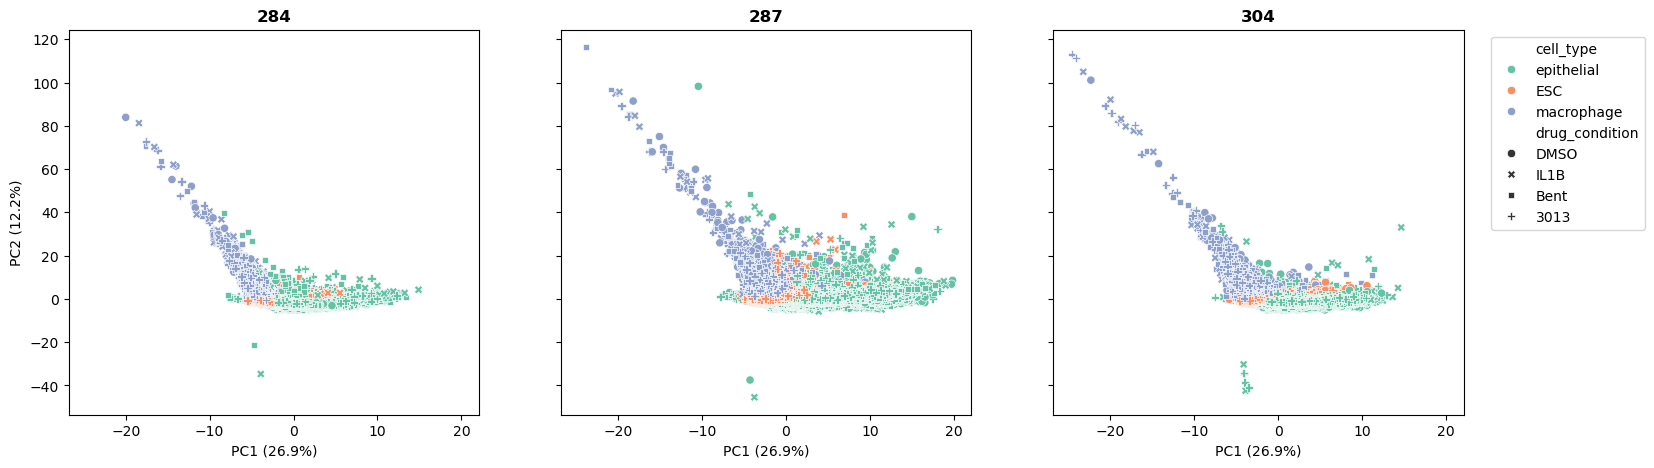

In [35]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, donor in zip(axs, (284, 287, 304)):

    subset = pc_df['donor_id'] == donor
    sns.scatterplot(data=pc_df[subset], x='PC1', y='PC2', 
                    hue='cell_type', style='drug_condition', palette='Set2', ax=ax)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(donor, fontweight='bold')

    if donor == 304:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

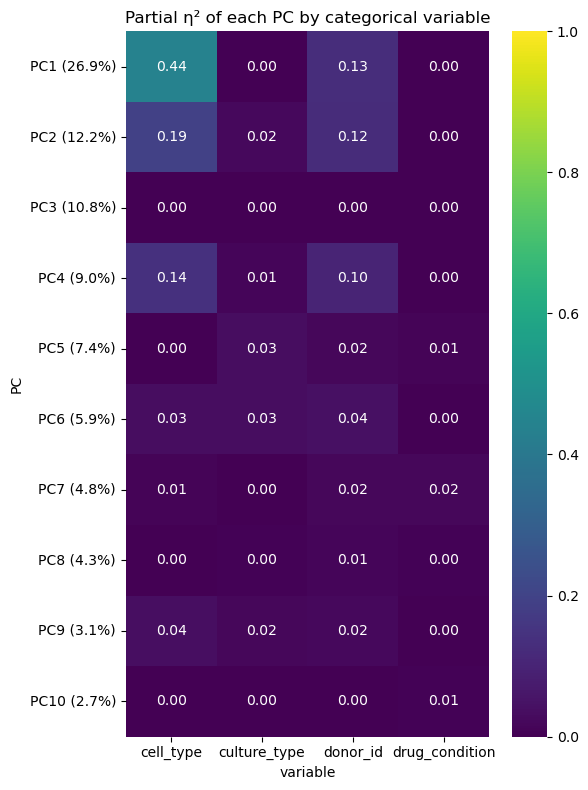

In [17]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(eta_pivot, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, ax=ax)
ax.set_title('Partial η² of each PC by categorical variable')

# annotate row labels with % variance explained by that PC
ax.set_yticklabels([f'{pc} ({pca.explained_variance_ratio_[i]:.1%})'
                     for i, pc in enumerate(pc_cols)], rotation=0)

fig.tight_layout()

In [18]:
well_means = df.groupby(['culture_type', 'rf_cell_type', 'drug_condition', 'well_id', 'donor_id']).mean().reset_index()
well_means

,culture_type,rf_cell_type,drug_condition,well_id,donor_id,nucleus_id,nuclear_volume_voxels,nuclear_volume_um3,cytoplasm_volume_voxels,cytoplasm_volume_um3,...,centroid_z,axis_major_length,axis_minor_length,nn_dist,nn_nucleus_id,nn5_mean_dist,num_neighbors_within_50_um,sphericity,aspect_ratio,nn5_mean_epcam
0,co,ESC,3013,B05,284,2085.408252,337.135722,777.853849,3040.129207,7014.315161,...,56.762021,26.941488,7.637735,24.737693,2082.527144,41.133948,3.583333,0.610860,3.718094,933.599355
1,co,ESC,3013,B05,287,4383.143078,490.046320,1130.655672,4296.846629,9913.866943,...,61.451865,29.772105,7.203461,34.601872,4399.538857,53.181566,2.068966,0.608763,4.262647,922.395731
2,co,ESC,3013,B05,304,2298.610196,384.276155,886.618258,3315.347584,7649.310681,...,59.943099,29.224001,7.562557,23.093087,2305.697026,38.765999,4.349442,0.601593,4.060419,964.634153
3,co,ESC,3013,C05,284,1983.421831,342.169414,789.467798,3038.067084,7009.557341,...,58.356192,26.433635,7.694331,25.142176,1988.274588,42.047501,3.576464,0.612072,3.609466,931.749284
4,co,ESC,3013,C05,287,4896.894273,420.566814,970.349605,4010.875918,9254.063179,...,61.013593,28.288550,6.906236,36.268333,4898.867841,55.761023,1.847283,0.606603,4.220157,961.732839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,tri,macrophage,IL1B,E03,287,4281.602843,389.993311,899.809122,3627.893813,8370.430609,...,26.513935,27.037797,7.199485,30.075778,4174.142977,43.389528,3.964047,0.621338,3.854754,1052.144635
356,tri,macrophage,IL1B,E03,304,2211.053473,253.930530,585.879299,2828.968007,6527.115076,...,37.258122,26.989800,6.947548,26.477101,2216.733090,42.007475,3.396252,0.624094,4.083181,1020.331324
357,tri,macrophage,IL1B,F03,284,2226.665330,213.695187,493.046607,2456.196524,5667.040886,...,54.454457,22.516793,6.983172,30.987293,2214.410428,46.145460,2.838681,0.646053,3.434270,974.556958
358,tri,macrophage,IL1B,F03,287,3347.797856,424.388974,979.168256,3727.869066,8601.097757,...,24.407252,27.656651,7.354912,28.693903,3300.148545,41.532411,4.289433,0.618004,3.866447,1072.483981


[0.38040507 0.2389756  0.10946133]


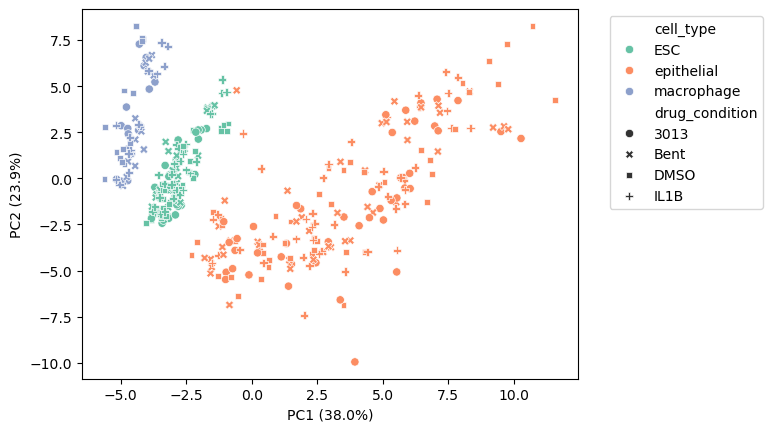

In [19]:
X = well_means[features]
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=3).fit(X_scaled)
pc = pca.transform(X_scaled)

print(pca.explained_variance_ratio_)

pc_df = pd.DataFrame(data=pc, columns=['PC1', 'PC2', 'PC3'])
pc_df['culture_type'] = well_means['culture_type']
pc_df['cell_type'] = well_means['rf_cell_type']
pc_df['drug_condition'] = well_means['drug_condition']
pc_df['donor_id'] = well_means['donor_id']

sns.scatterplot(data=pc_df, x='PC1', y='PC2', 
                hue='cell_type', style='drug_condition', palette='Set2')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

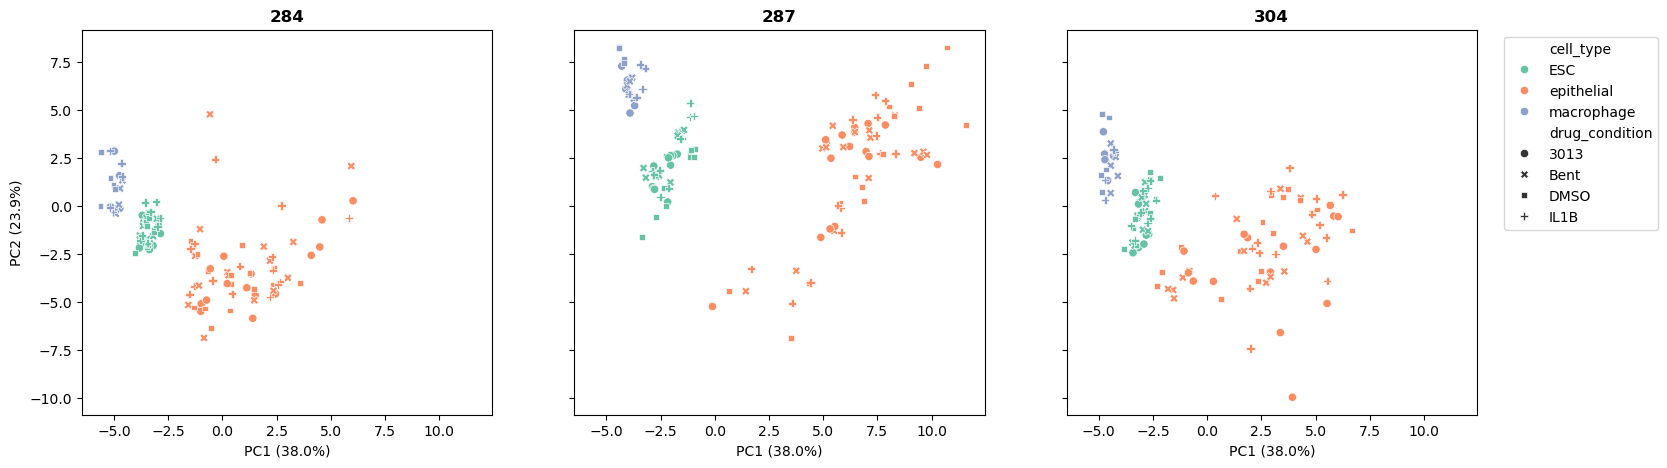

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, donor in zip(axs, (284, 287, 304)):

    subset = pc_df['donor_id'] == donor
    sns.scatterplot(data=pc_df[subset], x='PC1', y='PC2', 
                    hue='cell_type', style='drug_condition', palette='Set2', ax=ax)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(donor, fontweight='bold')

    if donor == 304:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

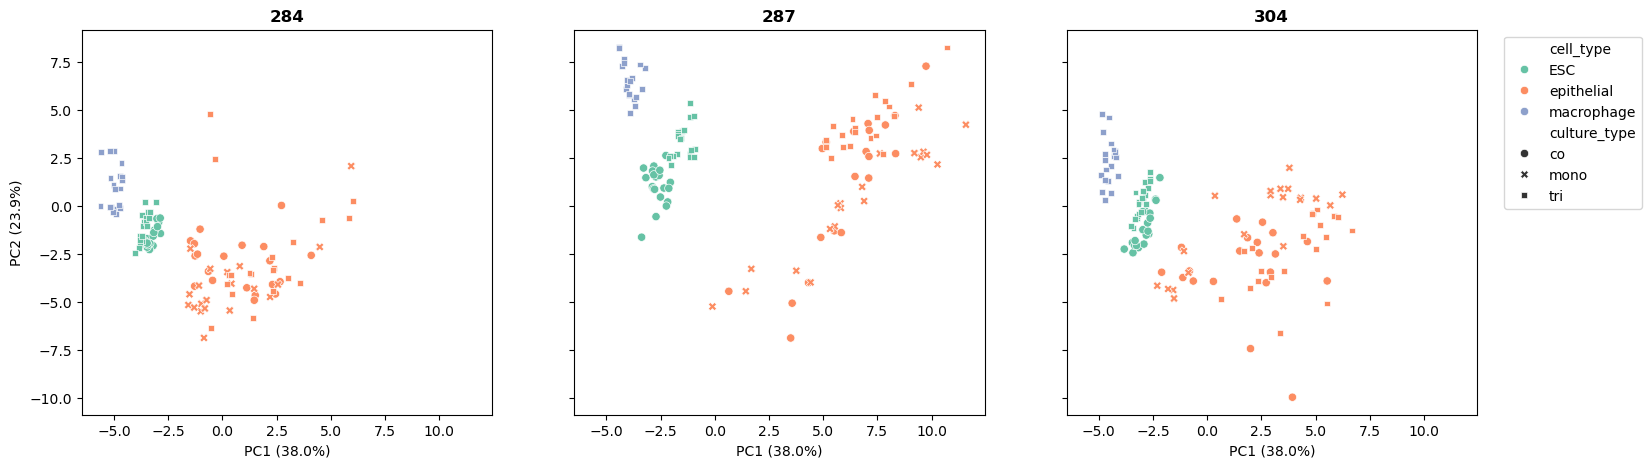

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, donor in zip(axs, (284, 287, 304)):

    subset = pc_df['donor_id'] == donor
    sns.scatterplot(data=pc_df[subset], x='PC1', y='PC2', 
                    hue='cell_type', style='culture_type', palette='Set2', ax=ax)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(donor, fontweight='bold')

    if donor == 304:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

In [5]:
def plot_by_culture(culture_type):

    sub_df = well_means[well_means['culture_type'] == culture_type]

    n_rows, n_cols = len(donors), len(cell_types)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 2.2 * n_rows),
        sharey=True,   # same y-scale across all panels
        sharex=True,
    )

    # Make axes always 2D for consistent indexing
    axes = axes.reshape(n_rows, n_cols)

    for i, donor in enumerate(donors):
        for j, cell_type in enumerate(cell_types):
            ax = axes[i, j]
            sub = sub_df[(sub_df['donor_id'] == donor) & (sub_df['rf_cell_type'] == cell_type)]

            sns.boxplot(
                data=sub, x='drug_condition', y='channel_2_nuclear_mean',
                order=drug_order, hue='drug_condition', hue_order=drug_order,
                palette=drug_colors, ax=ax, legend=False, flierprops={"marker": "."},
            )

            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_xticklabels(drug_order, rotation=45, ha='right')

            # Column labels only on top row
            if i == 0:
                ax.set_title(cell_type, fontsize=11)

            # Row labels only on rightmost column (margin_titles style)
            if j == n_cols-1:
                ax.annotate(
                    donor, xy=(1.05, 0.5), xycoords='axes fraction',
                    va='center', ha='left', fontsize=11
                )

    fig.subplots_adjust(wspace=0.5, hspace=0.15)
    fig.suptitle(f'{culture_type}culture Phospho-cJun', fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

In [24]:
def plot_by_cell_type(df, cell_type, channel_name, y_label=''):

    if 'rf_cell_type' in df.columns:
        df = df[df['rf_cell_type'] == cell_type]

    if cell_type == 'macrophage':
        culture_types = ['tri']
    elif cell_type == 'ESC':
        culture_types = ['co', 'tri']
    elif cell_type == 'epithelial':
        culture_types = ['mono', 'co', 'tri']
    else:
        raise ValueError(f'unknown cell type: {cell_type}')
    
    n_rows, n_cols = len(donors), len(culture_types)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 2.2 * n_rows),
        sharey=True,   # same y-scale across all panels
        sharex=True,
    )

    # Make axes always 2D for consistent indexing
    axes = axes.reshape(n_rows, n_cols)

    for i, donor in enumerate(donors):
        for j, culture_type in enumerate(culture_types):
            ax = axes[i, j]
            sub = df[(df['donor_id'] == donor) & (df['culture_type'] == culture_type)]

            sns.boxplot(
                data=sub, x='drug_condition', y=channel_name,
                hue='drug_condition',
                order=drug_order, hue_order=drug_order,
                palette=drug_colors,
                ax=ax, legend=False,
                fliersize=0,
                showcaps=True,
                fill=False,
            )

            sns.stripplot(
                data=sub, x='drug_condition', y=channel_name,
                hue='drug_condition',
                order=drug_order, hue_order=drug_order,
                palette=drug_colors,
                ax=ax, legend=False,
                dodge=False,
                size=3,
                alpha=0.6,
                linewidth=0.3,
                edgecolor='gray',
                jitter=0,
            )

            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_xticklabels(drug_order, rotation=45, ha='right')

            # Column labels only on top row
            if i == 0:
                ax.set_title(culture_type, fontsize=11, fontweight='bold')

            # Y axis label only on middle row
            if i == n_rows // 2:
                ax.set_ylabel(y_label, fontsize=11, fontweight='bold')

            # Row labels only on rightmost column (margin_titles style)
            if j == n_cols-1:
                ax.annotate(
                    donor, xy=(1.05, 0.5), xycoords='axes fraction',
                    va='center', ha='left', fontsize=11, fontweight='bold'
                )

    fig.subplots_adjust(wspace=0.5, hspace=0.15)
    fig.suptitle(f'{cell_type} {y_label}', fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

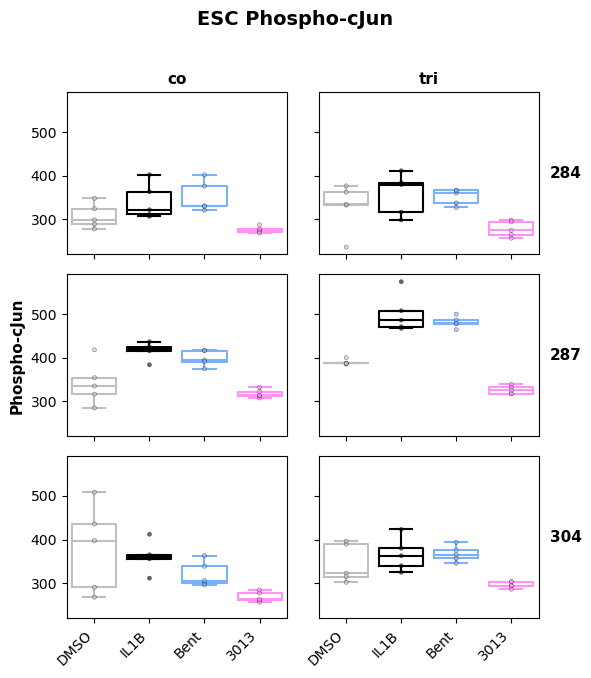

In [47]:
plot_by_cell_type(well_means, 'ESC', 'channel_2_nuclear_mean', y_label='Phospho-cJun')

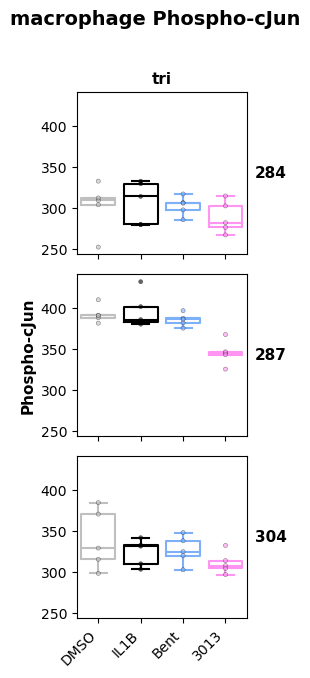

In [48]:
plot_by_cell_type(well_means, 'macrophage', 'channel_2_nuclear_mean', y_label='Phospho-cJun')

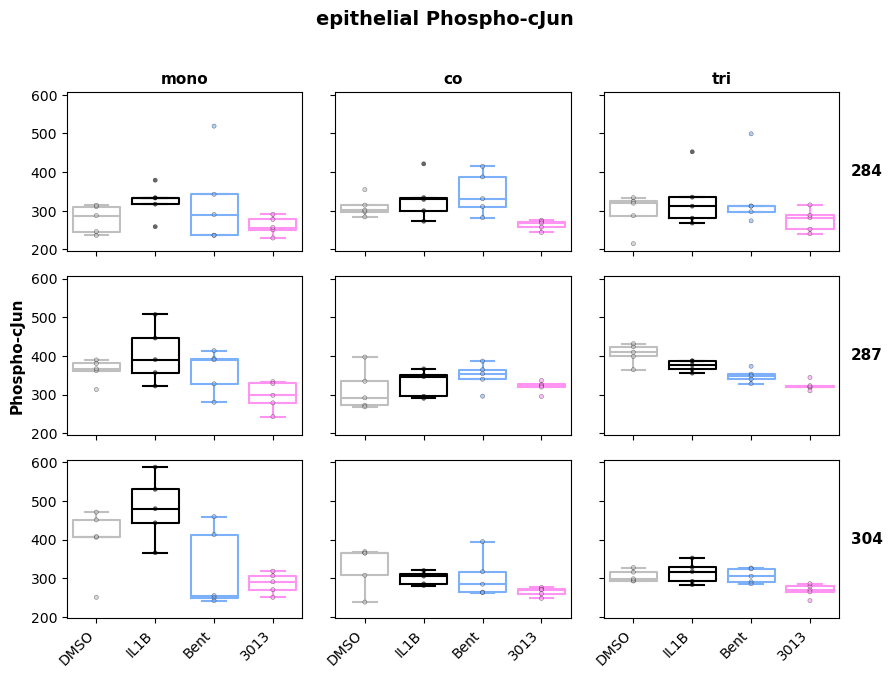

In [49]:
plot_by_cell_type(well_means, 'epithelial', 'channel_2_nuclear_mean', y_label='Phospho-cJun')

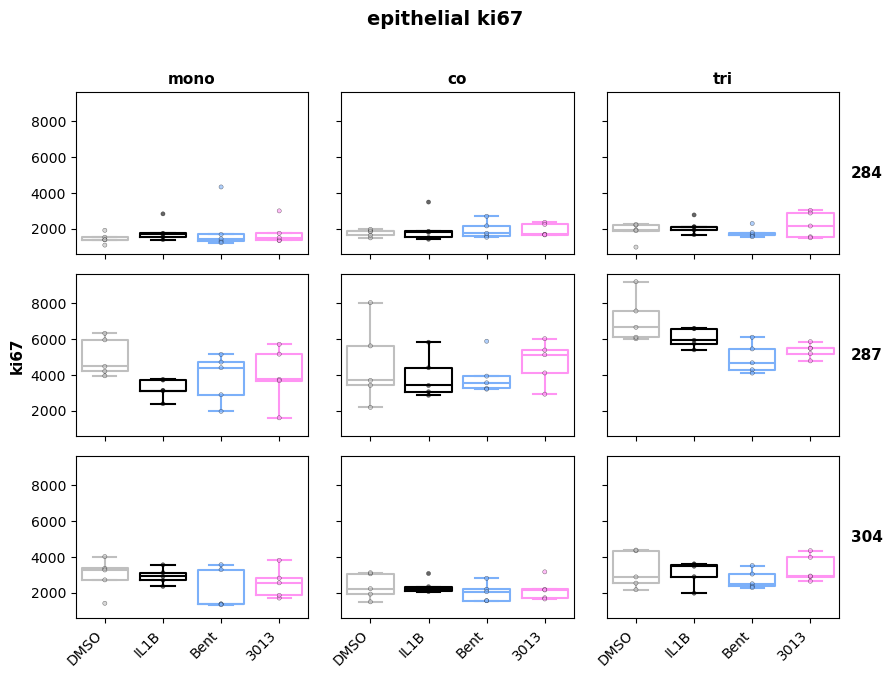

In [50]:
plot_by_cell_type(well_means, 'epithelial', 'channel_3_nuclear_mean', y_label='ki67')

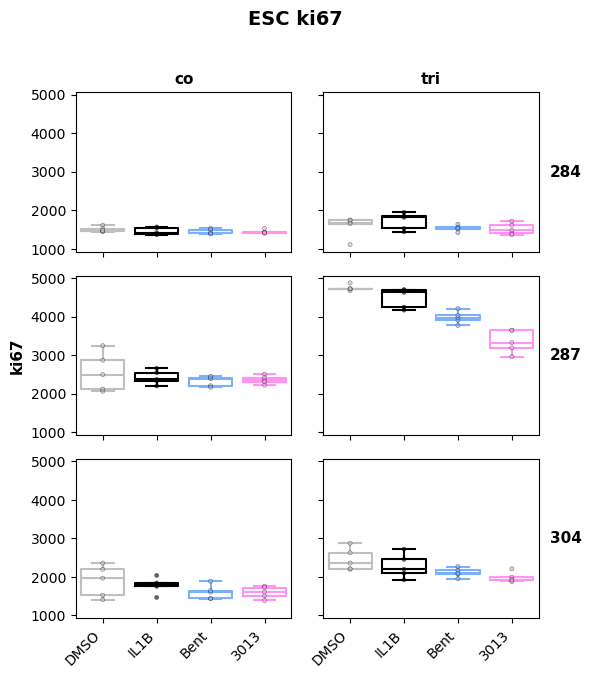

In [25]:
plot_by_cell_type(well_means, 'ESC', 'channel_3_nuclear_mean', y_label='ki67')

### Integrating EEO growth data and epithelial ki67 data

In [4]:
growth_df = pd.read_csv('/home/jdweiss1/orcd/scratch/15/eeo_growth_data.csv', index_col=0)

well_num = growth_df['well_id'].astype(str).str.extract(r'(\d+)$').astype(int)[0]
culture_thingy = growth_df['culture_thingy'].astype(str).str.strip()

growth_df['culture_type'] = np.select(
    [
        ((culture_thingy == 'mono-tri') & (well_num.isin([2, 3, 4, 5]))),
        (culture_thingy == 'co'),
        ((culture_thingy == 'mono-tri') & (well_num.isin([8, 9, 10, 11])))
    ],
    ['mono', 'co', 'tri'],
    default=''
)
growth_df = growth_df.drop(columns='culture_thingy')

growth_df['drug_condition'] = well_num.map(condition_map)

growth_df = growth_df.rename(columns={'donor': 'donor_id'})

growth_df

,track_id,n_timepoints,t_start,t_end,diameter_start,diameter_end,diameter_growth_rate,area_start,area_end,area_growth_rate,had_merge,well_id,donor_id,culture_type,drug_condition
0,4.0,5.0,0.0,4.0,33.888967,55.897494,5.627809,902.0,1420.0,404.1,False,B02,284,mono,DMSO
1,5.0,5.0,0.0,4.0,66.488252,66.813007,0.664816,3472.0,3643.0,73.8,False,B02,284,mono,DMSO
2,5.0,5.0,0.0,4.0,65.329159,88.324055,6.055717,3352.0,4140.0,737.8,False,B03,284,mono,IL1B
3,6.0,4.0,1.0,4.0,62.418851,74.455926,3.642827,3060.0,4086.0,391.8,False,B03,284,mono,IL1B
4,3.0,5.0,0.0,4.0,102.446638,182.057606,19.472942,8243.0,12473.0,4359.7,False,B04,284,mono,Bent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,3.0,3.0,0.0,2.0,31.875463,35.521548,1.823042,798.0,1158.0,96.5,True,E04,304,co,Bent
830,16.0,4.0,1.0,4.0,41.810978,42.655121,0.226350,1373.0,1435.0,15.0,False,E04,304,co,Bent
831,18.0,4.0,1.0,4.0,49.776743,74.207554,8.958737,1946.0,1742.0,855.1,False,E04,304,co,Bent
832,52.0,3.0,2.0,4.0,67.589818,126.111202,29.260692,3588.0,6826.0,4451.5,False,E04,304,co,Bent


In [5]:
growth_well_means = growth_df.groupby(['well_id', 'culture_type', 'drug_condition', 'donor_id'])[['diameter_end', 'diameter_growth_rate', 'area_end', 'area_growth_rate']].mean().reset_index()
growth_well_means

,well_id,culture_type,drug_condition,donor_id,diameter_end,diameter_growth_rate,area_end,area_growth_rate
0,B02,co,DMSO,284,40.954208,-1.825758,1721.000000,-125.900000
1,B02,co,DMSO,287,78.657050,11.067951,2205.333333,1146.600000
2,B02,co,DMSO,304,45.934262,3.594333,1408.250000,179.800000
3,B02,mono,DMSO,284,61.355250,3.146312,2531.500000,238.950000
4,B02,mono,DMSO,287,58.957992,7.578674,1355.272727,614.454545
...,...,...,...,...,...,...,...,...
130,F09,tri,IL1B,304,58.150778,5.128757,1665.000000,558.500000
131,F10,tri,Bent,284,49.946320,2.111699,2388.666667,121.400000
132,F11,tri,3013,284,29.918011,2.547318,771.000000,147.500000
133,F11,tri,3013,287,38.063556,0.024688,1369.000000,84.833333


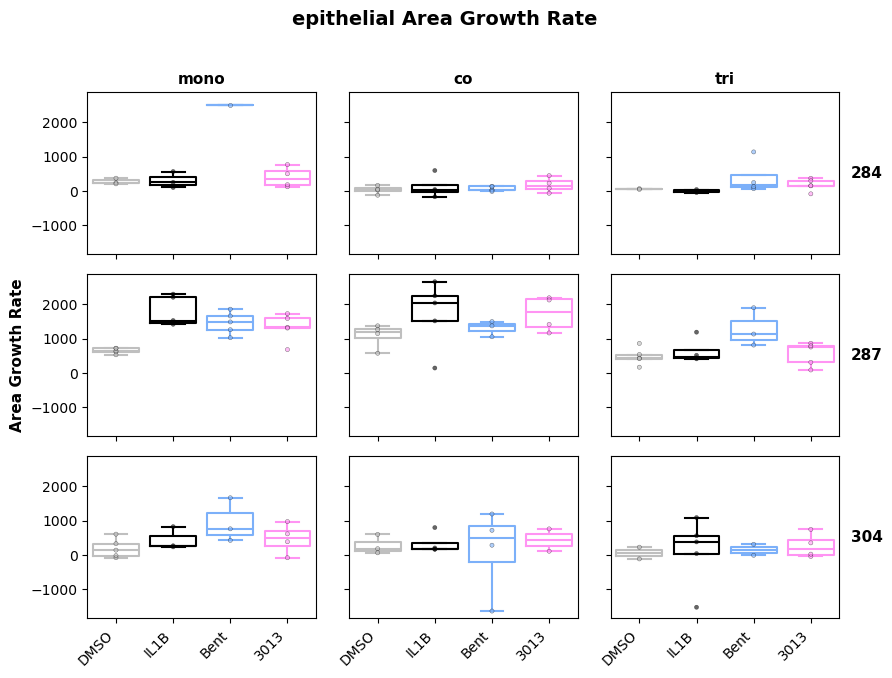

In [54]:
plot_by_cell_type(growth_well_means, 'epithelial', 'area_growth_rate', y_label='Area Growth Rate')

In [ ]:
merge_cols = ['well_id', 'culture_type', 'drug_condition', 'donor_id']

eeo_df = pd.merge(
    well_means[well_means['rf_cell_type'] == 'epithelial'][merge_cols + ['channel_3_nuclear_mean']],
    growth_well_means[merge_cols + ['area_growth_rate']],
    on=merge_cols
)
well_means['culture_type'].value_counts()

culture_type
co      46
mono    46
tri     43
Name: count, dtype: int64

Text(0.5, 1.0, 'EEO growth measurements')

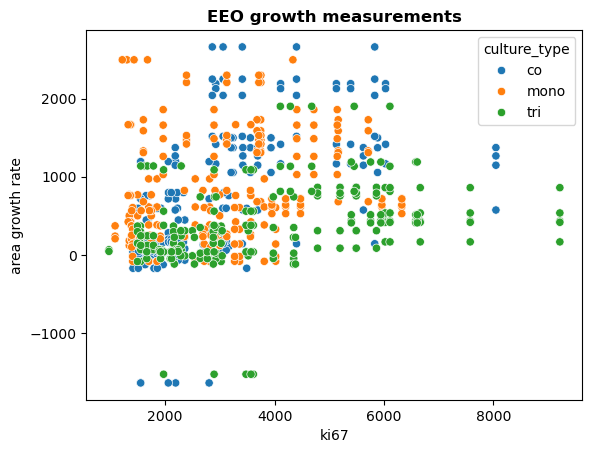

In [ ]:
sns.scatterplot(eeo_df, x='channel_3_nuclear_mean', y='area_growth_rate', hue='culture_type')
sns.lmplot(eeo_df, x='channel_3_nuclear_mean')
plt.xlabel('ki67')
plt.ylabel('area growth rate')
plt.title('EEO growth measurements', fontweight='bold')